<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
train_test_split,
cross_val_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
RandomForestClassifier,
ExtraTreesClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost --quiet
from catboost import CatBoostClassifier

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)

In [8]:
df = pd.read_csv("bank.csv")

In [9]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


# data cleaning

In [10]:
print("\nMissing Values Count")
print(df.isnull().sum())


Missing Values Count
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)



Duplicate Rows: 0


In [12]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = (
        df[col]
        .str.strip()      # Remove extra spaces
        .str.lower()      # Convert to lowercase
    )

print("\nCategorical Columns Cleaned")


Categorical Columns Cleaned


In [13]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 job
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

 marital
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

 education
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

 default
default
no     10994
yes      168
Name: count, dtype: int64

 housing
housing
no     5881
yes    5281
Name: count, dtype: int64

 loan
loan
no     9702
yes    1460
Name: count, dtype: int64

 contact
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

 month
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64

 p

In [14]:
numeric_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData Types After Validation")
print(df.dtypes)



Data Types After Validation
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [15]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"\nColumn: {col}")
    print("Outliers:", len(outliers))


Column: age
Outliers: 171

Column: balance
Outliers: 1055

Column: day
Outliers: 0

Column: duration
Outliers: 636

Column: campaign
Outliers: 601

Column: pdays
Outliers: 2750

Column: previous
Outliers: 1258


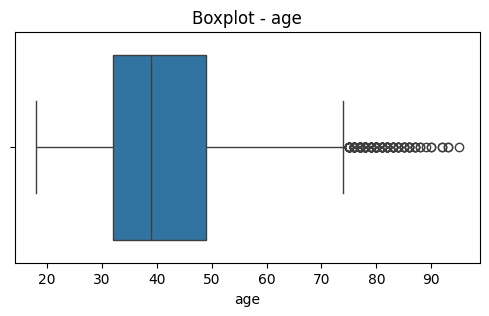

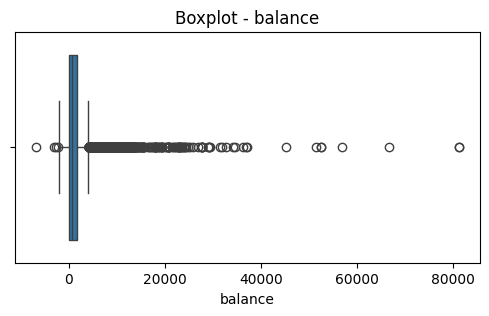

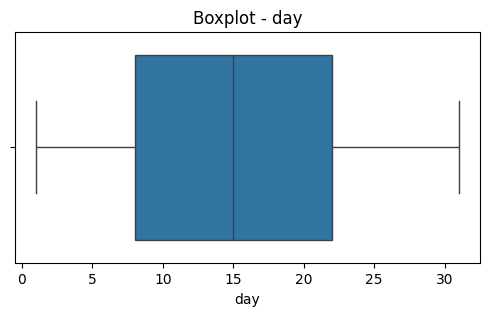

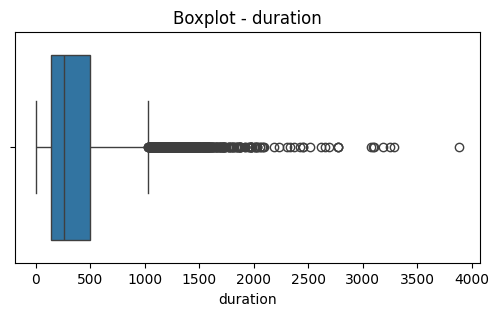

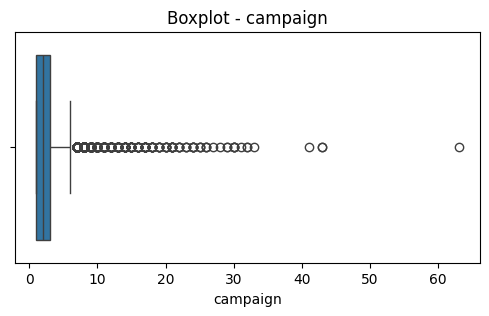

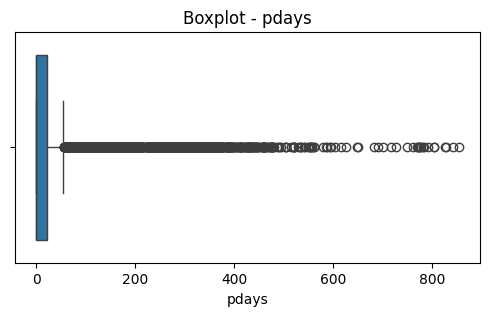

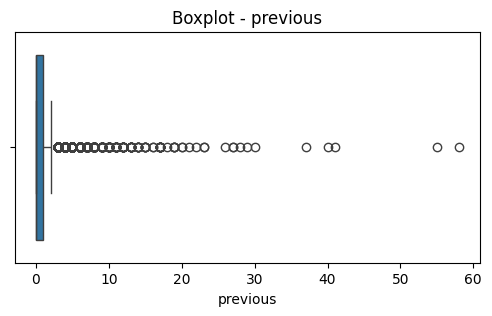

In [16]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

In [17]:
print("\nInvalid Age Records")
print(df[(df["age"] <= 0) | (df["age"] > 120)])

print("\nInvalid Duration Records")
print(df[df["duration"] < 0])

print("\nHigh Campaign Values")
print(df[df["campaign"] > 30])


Invalid Age Records
Empty DataFrame
Columns: [age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome, deposit]
Index: []

Invalid Duration Records
Empty DataFrame
Columns: [age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome, deposit]
Index: []

High Campaign Values
       age            job   marital  education default  balance housing loan  \
4912    50   entrepreneur   married    primary      no      461     yes   no   
6927    51    blue-collar   married    unknown      no       41     yes   no   
7139    42    blue-collar   married    primary      no      170     yes   no   
7237    42  self-employed   married   tertiary      no     1932     yes   no   
7240    33    blue-collar   married  secondary      no        0     yes  yes   
7635    45     management   married    unknown      no     9051     yes   no   
9683    49       se

In [18]:
month_map = {
    'jan':1,
    'feb':2,
    'mar':3,
    'apr':4,
    'may':5,
    'jun':6,
    'jul':7,
    'aug':8,
    'sep':9,
    'oct':10,
    'nov':11,
    'dec':12
}

df["month_num"] = df["month"].map(month_map)

# Quarter Feature
df["quarter"] = ((df["month_num"]-1)//3)+1

print("\nMonth & Quarter Features Created")


Month & Quarter Features Created


In [19]:
report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Data Type": df.dtypes.values
})

print("\nDATA QUALITY REPORT")
print(report)


DATA QUALITY REPORT
       Column  Missing Values Data Type
0         age               0     int64
1         job               0    object
2     marital               0    object
3   education               0    object
4     default               0    object
5     balance               0     int64
6     housing               0    object
7        loan               0    object
8     contact               0    object
9         day               0     int64
10      month               0    object
11   duration               0     int64
12   campaign               0     int64
13      pdays               0     int64
14   previous               0     int64
15   poutcome               0    object
16    deposit               0    object
17  month_num               0     int64
18    quarter               0     int64


# EDA ( exploratory data analytics )

In [20]:

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns


In [21]:
num_cols

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'month_num', 'quarter'],
      dtype='object')

In [22]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

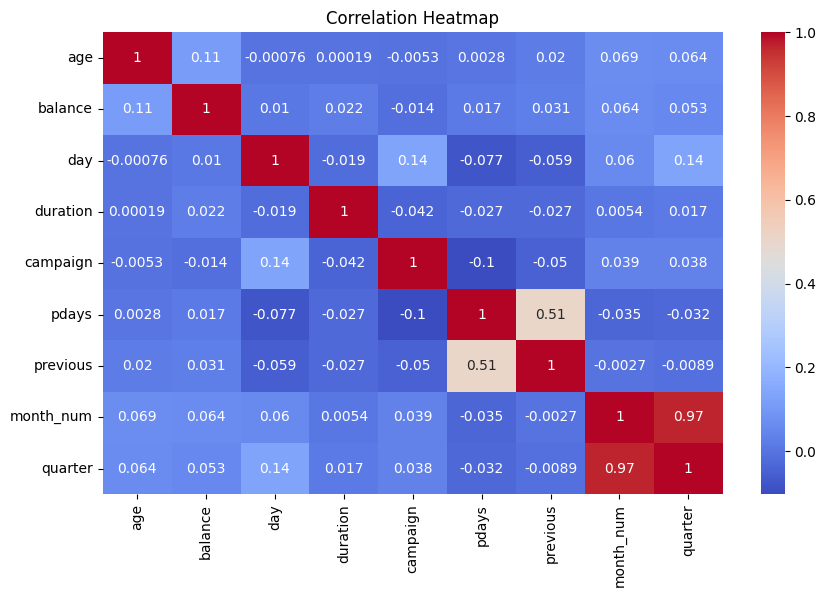

In [23]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

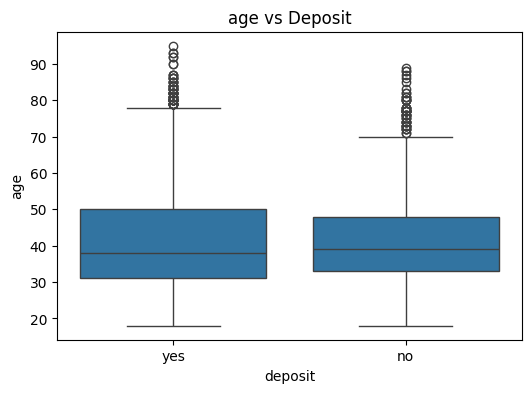

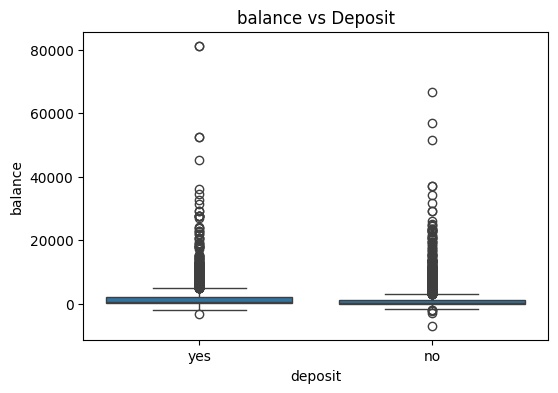

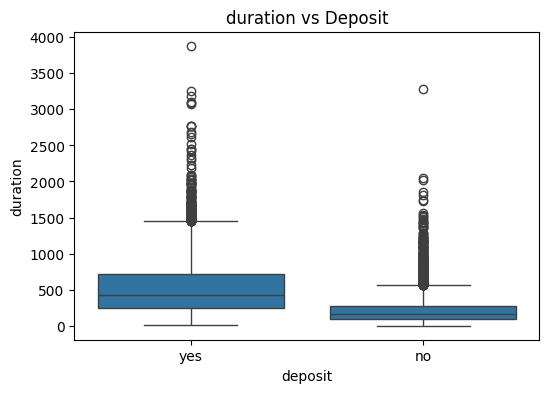

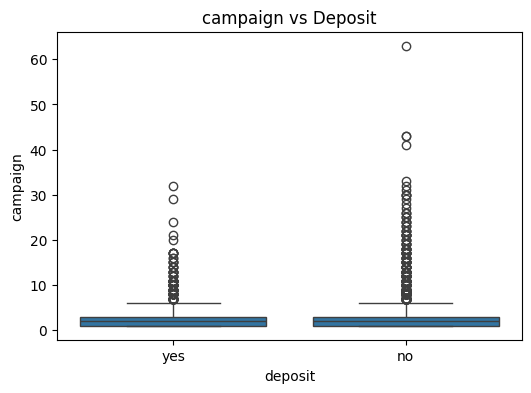

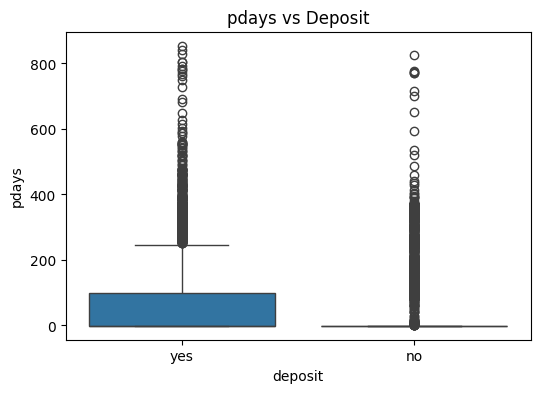

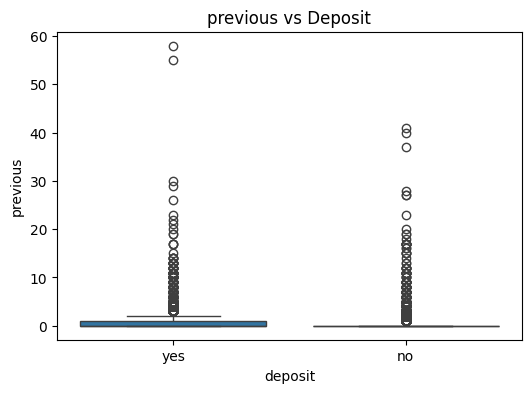

In [24]:
important_num = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

for col in important_num:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="deposit",
        y=col,
        data=df
    )

    plt.title(f"{col} vs Deposit")

    plt.show()

In [25]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,60,100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [26]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,month_num,quarter,age_group
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,5,2,46-60
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,5,2,46-60
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,5,2,36-45
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,5,2,46-60
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,5,2,46-60


# Feature engineering

customer generation

In [27]:
conditions = [
    df["age"] <= 28,
    (df["age"] > 28) & (df["age"] <= 44),
    (df["age"] > 44) & (df["age"] <= 60),
    df["age"] > 60
]

generations = [
    "Gen Z",
    "Millennial",
    "Gen X",
    "Boomer"
]

df["generation"] = np.select(
    conditions,
    generations,
    default="Unknown"
)

balance feature

In [28]:
df["balance_category"] = pd.qcut(
    df["balance"],
    q=4,
    labels=[
        "Low Balance",
        "Medium Balance",
        "High Balance",
        "Premium Customer"
    ]
)

log transformation

In [29]:
df["log_balance"] = np.log1p(
    np.maximum(df["balance"],0)
)

Campaign Features

In [30]:
df["contact_score"] = (
    df["campaign"] +
    df["previous"]
)

In [31]:
df["reach_efficiency"] = (
    df["previous"] /
    (df["campaign"] + 1)
)

engagement feature

In [32]:
df["engagement_score"] = (
    df["duration"] *
    df["previous"]
) / (df["campaign"] + 1)

In [33]:
df["contact_intensity"] = (
    df["duration"] /
    (df["campaign"] + 1)
)

season map

In [34]:
season_map = {
    12:"Winter",
    1:"Winter",
    2:"Winter",
    3:"Spring",
    4:"Spring",
    5:"Spring",
    6:"Summer",
    7:"Summer",
    8:"Summer",
    9:"Autumn",
    10:"Autumn",
    11:"Autumn"
}

df["season"] = df["month_num"].map(
    season_map
)

loan related

In [35]:
df["high_loan_burden"] = np.where(
    (df["housing"] == "yes") &
    (df["loan"] == "yes"),
    1,
    0
)

In [36]:
df["risk_score"] = (
    (df["housing"] == "yes").astype(int)
    +
    (df["loan"] == "yes").astype(int)
    +
    (df["default"] == "yes").astype(int)
)

previous compign features

In [37]:
df["previous_success"] = np.where(
    df["poutcome"] == "success",
    1,
    0
)

In [38]:
outcome_score = {
    "success":3,
    "other":2,
    "failure":1,
    "unknown":0
}

df["history_score"] = (
    df["previous"] *
    df["poutcome"].map(outcome_score)
)

interaction features

In [39]:
df["age_balance"] = (
    df["age"] *
    df["balance"]
)

In [40]:
df["duration_campaign"] = (
    df["duration"] *
    df["campaign"]
)

In [41]:
df["previous_duration"] = (
    df["previous"] *
    df["duration"]
)

In [42]:
df["age_previous"] = (
    df["age"] *
    df["previous"]
)

Encoding

In [43]:
target_encoder = LabelEncoder()

df["deposit"] = target_encoder.fit_transform(
    df["deposit"]
)

In [44]:
df = pd.get_dummies(
    df,
    columns=[
        "default",
        "housing",
        "loan"
    ],
    drop_first=True
)

In [45]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scale_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "log_balance",
    "contact_score",
    "engagement_score"
]

df[scale_cols] = scaler.fit_transform(
    df[scale_cols]
)

In [46]:
df.head(5)

,age,job,marital,education,balance,contact,day,month,duration,campaign,...,risk_score,previous_success,history_score,age_balance,duration_campaign,previous_duration,age_previous,default_yes,housing_yes,loan_yes
0,1.176471,admin.,married,secondary,1.130517,unknown,5,may,2.198324,-0.5,...,1,0,0,138237,1042,0,0,False,True,False
1,1.000000,admin.,married,secondary,-0.318411,unknown,5,may,3.385475,-0.5,...,0,0,0,2520,1467,0,0,False,False,False
2,0.117647,technician,married,secondary,0.453972,unknown,5,may,3.167598,-0.5,...,1,0,0,52070,1389,0,0,False,True,False
3,0.941176,services,married,secondary,1.214376,unknown,5,may,0.905028,-0.5,...,1,0,0,136180,579,0,0,False,True,False
4,0.882353,admin.,married,tertiary,-0.230769,unknown,5,may,1.167598,0.0,...,0,0,0,9936,1346,0,0,False,False,False


skewness analysis

In [47]:
num_cols = df.select_dtypes(
    include=np.number
).columns

skew_table = pd.DataFrame({
    "Skewness":
    df[num_cols].skew(),

    "Kurtosis":
    df[num_cols].kurtosis()
})

print(skew_table.sort_values(
    "Skewness",
    ascending=False
))

                    Skewness    Kurtosis
previous_duration  18.601844  674.207985
age_balance        15.788034  477.625116
engagement_score   15.243534  499.345481
balance             8.224619  126.861303
previous            7.335298  106.197826
age_previous        6.995734   96.669446
history_score       6.649959   79.325846
duration_campaign   6.549089   81.256580
reach_efficiency    6.400188   85.100298
campaign            5.545578   57.389771
contact_score       4.517212   39.437577
high_loan_burden    3.232852    8.452844
previous_success    2.744120    5.531185
pdays               2.449986    6.838359
contact_intensity   2.418796   10.014853
duration            2.143695    7.301282
age                 0.862780    0.621540
risk_score          0.594445   -0.393662
quarter             0.222836   -0.622693
month_num           0.191053   -0.353903
day                 0.111330   -1.061324
deposit             0.104798   -1.989374
log_balance        -1.034665    0.126151


In [48]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(
    method="yeo-johnson"
)

df[
    ["balance","campaign","pdays"]
] = pt.fit_transform(
    df[
        ["balance","campaign","pdays"]
    ]
)

feature selection

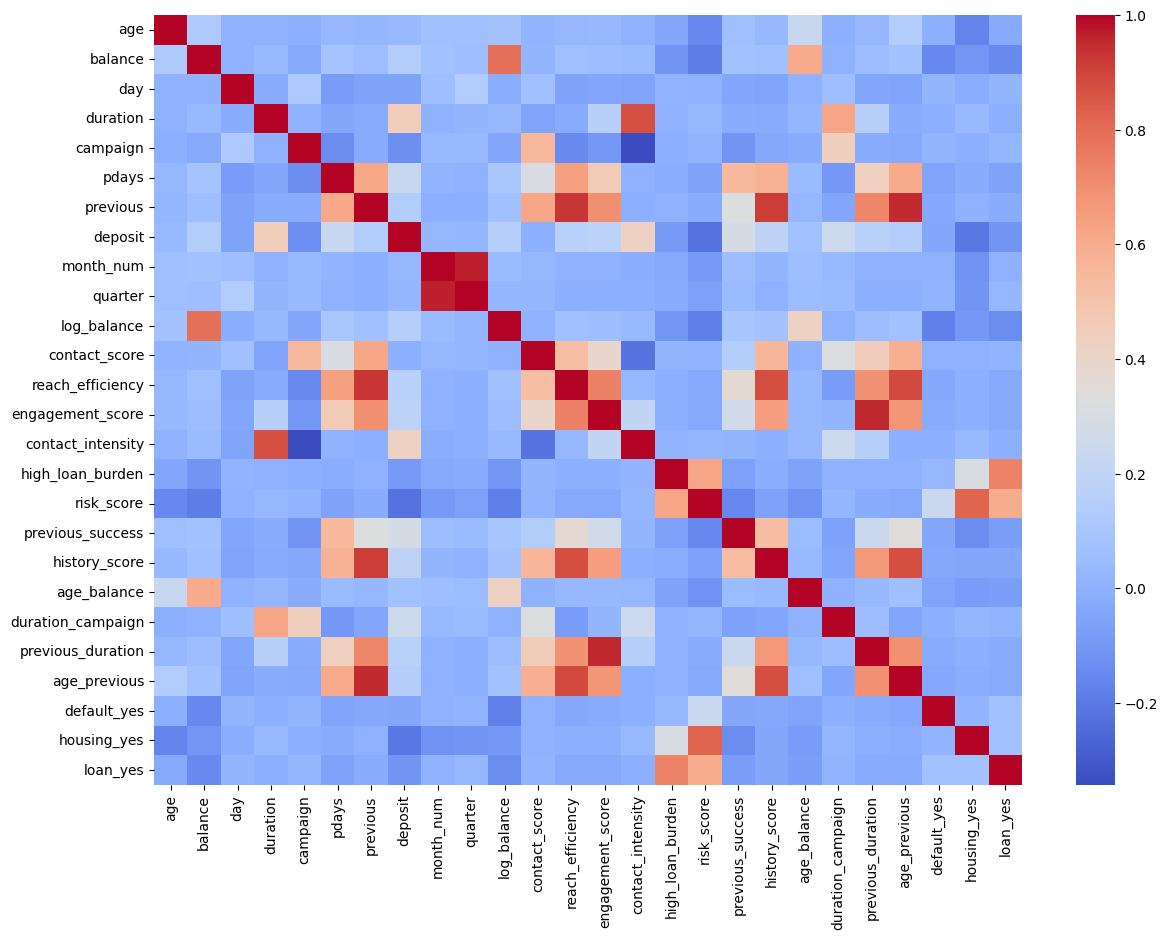

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [50]:
df.to_csv(
    "bank_feature_engineered.csv",
    index=False
)

print(
    "Feature Engineering Completed Successfully"
)

Feature Engineering Completed Successfully


# Train_test_split

In [51]:
X = df.drop(
columns=["deposit"]
)

y = df["deposit"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

evalution function

In [53]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name
):

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_pred
    )

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

    print("\n")
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred
    ))

    print("Confusion Matrix")
    print(confusion_matrix(
        y_test,
        y_pred
    ))

    return results

# logistic regression

In [54]:
log_model = LogisticRegression(
penalty="l2",
C=1.0,
solver="liblinear",
max_iter=1000,
random_state=42
)

# decision tree

In [55]:
dt_model = DecisionTreeClassifier(
criterion="gini",
max_depth=10,
min_samples_split=10,
min_samples_leaf=5,
random_state=42
)

# Random forest

In [56]:
rf_model = RandomForestClassifier(
n_estimators=300,
max_depth=15,
min_samples_split=5,
min_samples_leaf=2,
bootstrap=True,
random_state=42,
n_jobs=-1
)

# Extra trees

In [57]:
et_model = ExtraTreesClassifier(
n_estimators=300,
max_depth=15,
min_samples_split=5,
random_state=42,
n_jobs=-1
)

# XG boost

In [58]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Light BGM

In [59]:
lgbm_model = LGBMClassifier(
n_estimators=300,
learning_rate=0.05,
num_leaves=31,
max_depth=-1,
random_state=42
)

# Cat Boost

In [60]:
cat_model = CatBoostClassifier(
iterations=300,
depth=6,
learning_rate=0.05,
loss_function="Logloss",
verbose=0,
random_state=42
)

# contains object to that try to solve using remove that or replace it

In [61]:
print(X.dtypes[X.dtypes == "object"])

job           object
marital       object
education     object
contact       object
month         object
poutcome      object
generation    object
season        object
dtype: object


In [62]:
for col in X.select_dtypes(include="object").columns:
    print("\n", col)
    print(X[col].unique())


 job
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

 marital
['married' 'single' 'divorced']

 education
['secondary' 'tertiary' 'primary' 'unknown']

 contact
['unknown' 'cellular' 'telephone']

 month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

 poutcome
['unknown' 'other' 'failure' 'success']

 generation
['Gen X' 'Millennial' 'Gen Z' 'Boomer']

 season
['Spring' 'Summer' 'Autumn' 'Winter']


In [63]:
binary_cols = [
    "default_yes",
    "housing_yes",
    "loan_yes"
]

for col in binary_cols:
    X[col] = X[col].astype(int)

In [64]:
X["quarter"] = X["quarter"].map({
    "Q1":1,
    "Q2":2,
    "Q3":3,
    "Q4":4
})

In [65]:
print(
    X.select_dtypes(
        include="object"
    ).columns
)

Index(['job', 'marital', 'education', 'contact', 'month', 'poutcome',
       'generation', 'season'],
      dtype='object')


In [66]:
print("Object Columns Remaining")

obj_cols = X.select_dtypes(
    include="object"
).columns

print(obj_cols)

for col in obj_cols:
    print("\nColumn:", col)
    print(X[col].unique()[:10])

Object Columns Remaining
Index(['job', 'marital', 'education', 'contact', 'month', 'poutcome',
       'generation', 'season'],
      dtype='object')

Column: job
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown']

Column: marital
['married' 'single' 'divorced']

Column: education
['secondary' 'tertiary' 'primary' 'unknown']

Column: contact
['unknown' 'cellular' 'telephone']

Column: month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar']

Column: poutcome
['unknown' 'other' 'failure' 'success']

Column: generation
['Gen X' 'Millennial' 'Gen Z' 'Boomer']

Column: season
['Spring' 'Summer' 'Autumn' 'Winter']


In [67]:
X.select_dtypes(include="object").columns

Index(['job', 'marital', 'education', 'contact', 'month', 'poutcome',
       'generation', 'season'],
      dtype='object')

In [68]:
print(X.isnull().sum()[X.isnull().sum() > 0])

quarter      11162
age_group        8
dtype: int64


In [69]:
print("Total Missing Values:")
print(X.isnull().sum().sum())

Total Missing Values:
11170


In [70]:
nan_rows = X[X.isnull().any(axis=1)]

print(nan_rows.head())

        age         job  marital  education   balance  contact  day month  \
0  1.176471      admin.  married  secondary  0.876127  unknown    5   may   
1  1.000000      admin.  married  secondary -0.822314  unknown    5   may   
2  0.117647  technician  married  secondary  0.347704  unknown    5   may   
3  0.941176    services  married  secondary  0.926925  unknown    5   may   
4  0.882353      admin.  married   tertiary -0.635503  unknown    5   may   

   duration  campaign  ...  risk_score  previous_success history_score  \
0  2.198324 -1.035925  ...           1                 0             0   
1  3.385475 -1.035925  ...           0                 0             0   
2  3.167598 -1.035925  ...           1                 0             0   
3  0.905028 -1.035925  ...           1                 0             0   
4  1.167598  0.253540  ...           0                 0             0   

   age_balance  duration_campaign previous_duration age_previous default_yes  \
0       1382

replace column

In [71]:
numeric_cols = X.select_dtypes(
include=np.number
).columns

for col in numeric_cols:
    X[col] = X[col].fillna(
    X[col].median()
)

In [72]:
categorical_cols = X.select_dtypes(
exclude=np.number
).columns

for col in categorical_cols:
    X[col] = X[col].fillna(
    X[col].mode()[0]
)

In [73]:
print("Missing Values Per Column")

missing = X.isnull().sum()

print(
missing[missing > 0]
)


Missing Values Per Column
quarter    11162
dtype: int64


In [74]:
print(X.columns.tolist())

['age', 'job', 'marital', 'education', 'balance', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'month_num', 'quarter', 'age_group', 'generation', 'balance_category', 'log_balance', 'contact_score', 'reach_efficiency', 'engagement_score', 'contact_intensity', 'season', 'high_loan_burden', 'risk_score', 'previous_success', 'history_score', 'age_balance', 'duration_campaign', 'previous_duration', 'age_previous', 'default_yes', 'housing_yes', 'loan_yes']


In [75]:
X = X.drop(columns=["quarter"], errors="ignore")

In [76]:
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


# Train all models

In [77]:
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=['object', 'category']).columns,
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

results = []

results.append(
    evaluate_model(
        log_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        dt_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Decision Tree"
    )
)

results.append(
    evaluate_model(
        rf_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        et_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Extra Trees"
    )
)

results.append(
    evaluate_model(
        xgb_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "XGBoost"
    )
)

results.append(
    evaluate_model(
        lgbm_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "LightGBM"
    )
)

results.append(
    evaluate_model(
        cat_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "CatBoost"
    )
)



Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1175
           1       0.80      0.78      0.79      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233

Confusion Matrix
[[964 211]
 [233 825]]


Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1175
           1       0.79      0.80      0.80      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233

Confusion Matrix
[[952 223]
 [210 848]]


Random Forest
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.82      0.89      0.85      1058

    accuracy                           0.85     

# Hyper parameter tuning

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [79]:
# from sklearn.tree import DecisionTreeClassifier


# dt_params = {
#     "criterion": ["gini", "entropy"],
#     "max_depth": [5, 10, 15, 20],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 5],
#     "max_features": [None, "sqrt", "log2"]
# }

# dt_grid = GridSearchCV(
#     estimator=DecisionTreeClassifier(
#         random_state=42
#     ),
#     param_grid=dt_params,
#     scoring="roc_auc",
#     cv=cv,
#     n_jobs=-1,
#     verbose=1
# )

# dt_grid.fit(X_train, y_train)

# print(dt_grid.best_params_)
# print(dt_grid.best_score_)

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
0.9140997439723756


In [81]:
# from sklearn.model_selection import RandomizedSearchCV

# rf_random = {
#     "n_estimators": [100, 200, 300, 500, 800],
#     "max_depth": [5, 10, 15, 20, None],
#     "min_samples_split": [2, 5, 10, 15],
#     "min_samples_leaf": [1, 2, 4, 6],
#     "max_features": ["sqrt", "log2"],
#     "bootstrap": [True, False]
# }

# rf_random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(
#         random_state=42
#     ),
#     param_distributions=rf_random,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=cv,
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# rf_random_search.fit(
#     X_train,
#     y_train
# )

# print(
#     rf_random_search.best_params_
# )

# print(
#     rf_random_search.best_score_
# )

In [82]:
from sklearn.ensemble import ExtraTreesClassifier

et_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_distributions=et_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

et_search.fit(X_train, y_train)

print(et_search.best_params_)
print(et_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20}
0.9120833061660432


In [83]:
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print(xgb_search.best_params_)#
print(xgb_search.best_score_)

{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
0.9237646913574684


In [84]:
from lightgbm import LGBMClassifier

lgbm_params = {
    "num_leaves": [31, 50],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    param_distributions=lgbm_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

print(lgbm_search.best_params_)
print(lgbm_search.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4231, number of negative: 4698
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2942
[LightGBM] [Info] Number of data points in the train set: 8929, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473849 -> initscore=-0.104699
[LightGBM] [Info] Start training from score -0.104699
{'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.05}
0.9247559753589569


In [85]:
from catboost import CatBoostClassifier

cat_params = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

cat_search = RandomizedSearchCV(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    param_distributions=cat_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

cat_search.fit(X_train, y_train)

print(cat_search.best_params_)
print(cat_search.best_score_)

{'learning_rate': 0.1, 'iterations': 200, 'depth': 6}
0.9270761327710457


In [86]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

dt_search.fit(X_train, y_train)

print(dt_search.best_params_)
print(dt_search.best_score_)

{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}
0.8710632893729399


**evalure and compare all model**

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

tuning_results = []

def evaluate_tuned_model(
    search_object,
    model_name
):

    best_model = search_object.best_estimator_

    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:,1]

    tuning_results.append({

        "Model": model_name,

        "Accuracy":
        round(
            accuracy_score(
                y_test,
                y_pred
            ),
            4
        ),

        "Precision":
        round(
            precision_score(
                y_test,
                y_pred
            ),
            4
        ),

        "Recall":
        round(
            recall_score(
                y_test,
                y_pred
            ),
            4
        ),

        "F1":
        round(
            f1_score(
                y_test,
                y_pred
            ),
            4
        ),

        "ROC_AUC":
        round(
            roc_auc_score(
                y_test,
                y_prob
            ),
            4
        ),

        "Best_Params":
        str(
            search_object.best_params_
        )

    })

In [88]:
evaluate_tuned_model(
    dt_search,
    "Decision Tree"
)

evaluate_tuned_model(
    rf_search,
    "Random Forest"
)

evaluate_tuned_model(
    et_search,
    "Extra Trees"
)

evaluate_tuned_model(
    xgb_search,
    "XGBoost"
)

evaluate_tuned_model(
    lgbm_search,
    "LightGBM"
)

evaluate_tuned_model(
    cat_search,
    "CatBoost"
)

In [89]:
comparison = pd.DataFrame(
    tuning_results
)

comparison = comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Best_Params
5,CatBoost,0.8706,0.8436,0.8922,0.8672,0.9321,"{'learning_rate': 0.1, 'iterations': 200, 'dep..."
4,LightGBM,0.8665,0.8345,0.8960,0.8642,0.9303,"{'num_leaves': 31, 'n_estimators': 200, 'learn..."
3,XGBoost,0.8625,0.8350,0.8847,0.8591,0.9299,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
2,Extra Trees,0.8527,0.8323,0.8629,0.8473,0.9196,"{'n_estimators': 200, 'min_samples_split': 5, ..."
1,Random Forest,0.8518,0.8175,0.8847,0.8498,0.9195,"{'n_estimators': 200, 'min_samples_split': 2, ..."
0,Decision Tree,0.8065,0.7684,0.8469,0.8058,0.8732,"{'min_samples_split': 2, 'min_samples_leaf': 1..."


In [90]:
comparison[
    ["Model", "Best_Params"]
]

,Model,Best_Params
5,CatBoost,"{'learning_rate': 0.1, 'iterations': 200, 'dep..."
4,LightGBM,"{'num_leaves': 31, 'n_estimators': 200, 'learn..."
3,XGBoost,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
2,Extra Trees,"{'n_estimators': 200, 'min_samples_split': 5, ..."
1,Random Forest,"{'n_estimators': 200, 'min_samples_split': 2, ..."
0,Decision Tree,"{'min_samples_split': 2, 'min_samples_leaf': 1..."


In [91]:
best_model_row = comparison.iloc[0]

print(
    "Best Tuned Model:"
)

print(
    best_model_row["Model"]
)

print(
    "ROC_AUC:",
    best_model_row["ROC_AUC"]
)

print(
    "Parameters:"
)

print(
    best_model_row["Best_Params"]
)

Best Tuned Model:
CatBoost
ROC_AUC: 0.9321
Parameters:
{'learning_rate': 0.1, 'iterations': 200, 'depth': 6}


***hyper parameter tuning result***

In [92]:
tuning_summary = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "CV_Best_Score": [
        dt_search.best_score_,
        rf_search.best_score_,
        et_search.best_score_,
        xgb_search.best_score_,
        lgbm_search.best_score_,
        cat_search.best_score_
    ],

    "Best_Params": [
        str(dt_search.best_params_),
        str(rf_search.best_params_),
        str(et_search.best_params_),
        str(xgb_search.best_params_),
        str(lgbm_search.best_params_),
        str(cat_search.best_params_)
    ]
})

tuning_summary

,Model,CV_Best_Score,Best_Params
0,Decision Tree,0.871063,"{'min_samples_split': 2, 'min_samples_leaf': 1..."
1,Random Forest,0.914100,"{'n_estimators': 200, 'min_samples_split': 2, ..."
2,Extra Trees,0.912083,"{'n_estimators': 200, 'min_samples_split': 5, ..."
3,XGBoost,0.923765,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
4,LightGBM,0.924756,"{'num_leaves': 31, 'n_estimators': 200, 'learn..."
5,CatBoost,0.927076,"{'learning_rate': 0.1, 'iterations': 200, 'dep..."


# Deployment

In [93]:
import joblib

# Save trained model
joblib.dump(rf_model, "random_forest_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature column names after encoding
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("All files saved successfully")

All files saved successfully


In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

joblib.dump(
    full_pipeline,
    "bank_rf_pipeline.pkl"
)

NameError: name 'preprocessor' is not defined

In [ ]:
print(X.columns.tolist())

# **train new only 8 or 9 feature not 72 entire**

In [ ]:
features = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "housing_yes",
    "loan_yes",
    "poutcome"
]

X = df[features]
y = df["deposit"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [ ]:
X = pd.get_dummies(
    X,
    columns=["poutcome"],
    drop_first=True
)

In [ ]:
for col in ["housing", "loan", "poutcome"]:
    print(col, col in X.columns)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_pred = rf_model.predict(X_test_scaled)

rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]

print("Random Forest Results")
print("="*50)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

In [ ]:
xgb_pred = xgb_model.predict(X_test_scaled)

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:,1]

print("XGBoost Results")
print("="*50)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

In [ ]:
import joblib

joblib.dump(
    rf_model,
    "bank_rf_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

joblib.dump(
    target_encoder,
    "target_encoder.pkl"
)

# **DEEP LEARNING CONCEPT**

In [ ]:
pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
deep_data = pd.read_csv("bank_feature_engineered.csv")

In [ ]:
for col in ["default", "housing", "loan"]:
    if col in df.columns:
        df[col] = df[col].map({
            "yes": 1,
            "no": 0
        })

In [ ]:
target = 'deposit'

X = df.drop(target, axis=1)
y = df[target]

X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, "scaler_deep.pkl")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model.add(Dropout(0.3))

model.add(Dense(
    64,
    activation='relu'
))

model.add(Dropout(0.2))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [ ]:

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

In [ ]:

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(f"Accuracy: {accuracy*100:.2f}%")

In [ ]:
model.save("model_deep.keras")

In [ ]:
X = pd.get_dummies(X, drop_first=True)

joblib.dump(X.columns.tolist(), "feature_columns_deep.pkl")

## Feature selection

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Ensure 'deposit' column in deep_data is correctly encoded
# It seems to have been loaded as NaN or non-numeric after saving to CSV.
# We will re-encode it from the original 'bank.csv' source.
original_df_deposit = pd.read_csv("bank.csv")['deposit']
le = LabelEncoder()
deep_data["deposit"] = le.fit_transform(original_df_deposit)
print("Re-encoded 'deposit' column in deep_data to numerical values.")

In [ ]:
deep_data['deposit'].head(5)

In [ ]:
numeric_deep_data = deep_data.select_dtypes(include=["number"])

In [ ]:
numeric_deep_data.head(5)

In [ ]:
corr_with_target = (
    numeric_deep_data.corr()["deposit"]
    .sort_values(ascending=False)
)

print("Correlation with Deposit:")
print(corr_with_target)


In [ ]:
features_new_data = [
    "duration",
    "contact_intensity",
    "duration_campaign",
    "history_score",
    "pdays",
    "engagement_score",
    "reach_efficiency",
    "previous_duration",
]

In [ ]:
print(deep_data["deposit"].unique())
print(deep_data["deposit"].dtype)

In [ ]:
from sklearn.model_selection import train_test_split

X = deep_data[features_new_data]
y = deep_data["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

Random forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

XG bosst

In [ ]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))
    print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

In [ ]:
evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)

Comparision

In [ ]:
results = []

for name, model in [
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model)
]:

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

comparison_df